# Лабораторная работа №1: Обязательная часть
### Однослойный перцептрон: реализация, обучение и анализ

**Цели ноутбука:**
1. Подготовка синтетических данных (генерация, стратифицированное разбиение, Z-score стандартизация).
2. Обучение базовой модели перцептрона с нуля.
3. Оценка качества обучения и визуализация результатов.
4. Проведение экспериментов (влияние темпа обучения, размера батча и инициализации весов).

In [1]:
import sys
import os
# Добавляем родительскую директорию в path, чтобы импортировать модули из src/
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.data_generator import get_sklearn_data
from src.preprocessing import train_test_split_stratified, StandardScaler
from src.perceptron import Perceptron
from src.metrics import accuracy_score
from src.visualization import plot_learning_curve, plot_decision_boundary

## 1. Подготовка данных

Сгенерируем датасет для бинарной классификации с помощью встроенных средств библиотеки `scikit-learn` согласно спецификациям ТЗ. Разделим выборку на обучающую и тестовую в пропорции 70/30 с применением стратификации. Затем нормализуем признаки с помощью Z-score стандартизации.

In [15]:
# Генерация данных
X, y = get_sklearn_data()

# Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split_stratified(X, y, test_size=0.3, random_state=42)

# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train_scaled.shape}, тестовой: {X_test_scaled.shape}")
print(f"Распределение классов в трейне: {np.bincount(y_train)}")
print(f"Распределение классов в тесте:  {np.bincount(y_test)}")

Размер обучающей выборки: (351, 2), тестовой: (149, 2)
Распределение классов в трейне: [175 176]
Распределение классов в тесте:  [74 75]


## 2. Обучение перцептрона и визуализация базового решения

Запустим процесс обучения модели на базовых параметрах:
*   Скорость обучения ($\eta$) = 0.1
*   Эпохи = 100
*   Размер батча = 32

In [5]:
# Обучение модели
np.random.seed(42)
model = Perceptron(input_size=2, loss_fn='bce')
history = model.fit(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    epochs=100,
    lr=0.1,
    batch_size=32
)

# Оценка точности
train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train.reshape(-1, 1), train_preds)
test_acc = accuracy_score(y_test.reshape(-1, 1), test_preds)

print(f"Точность на обучении: {train_acc:.4f}")
print(f"Точность на тесте:    {test_acc:.4f}")

Точность на обучении: 0.8632
Точность на тесте:    0.9060


# Обучение модели
np.random.seed(42)
model = Perceptron(input_size=2, loss_fn='bce')
history = model.fit(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    epochs=100,
    lr=0.1,
    batch_size=32
)

# Оценка точности
train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train.reshape(-1, 1), train_preds)
test_acc = accuracy_score(y_test.reshape(-1, 1), test_preds)

print(f"Точность на обучении: {train_acc:.4f}")
print(f"Точность на тесте:    {test_acc:.4f}")## 3. Эксперименты и анализ параметров

### Эксперимент 1: Влияние скорости обучения (learning rate)
Опробуем значения $\eta \in \{0.001, 0.01, 0.5, 1.0\}$ при фиксированном размере батча 32 и 100 эпохах.

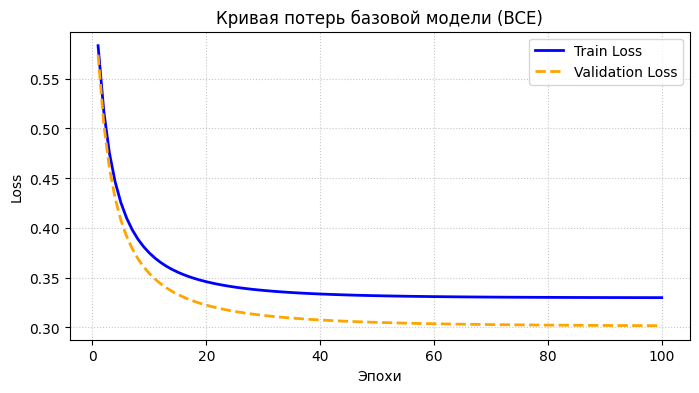

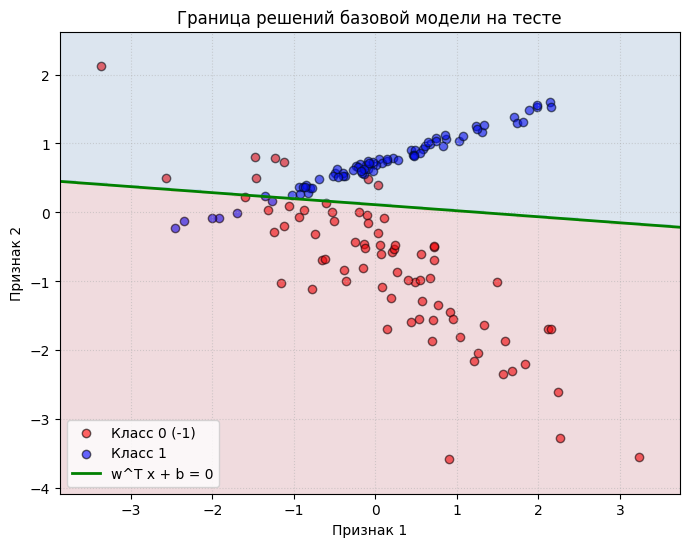

In [8]:
# Построение графиков функции потерь
plot_learning_curve(history['train_loss'], history['val_loss'], title="Кривая потерь базовой модели (BCE)")

# Отрисовка разделяющей границы решений на тестовых данных
plot_decision_boundary(X_test_scaled, y_test, model, title="Граница решений базовой модели на тесте")

## 3. Эксперименты и анализ параметров

### Эксперимент 1: Влияние скорости обучения (learning rate)
Опробуем значения $\eta \in \{0.001, 0.01, 0.5, 1.0\}$ при фиксированном размере батча 32 и 100 эпохах.

Learning Rate   | Train Accuracy  | Test Accuracy  
-----------------------------------------------------
0.001           | 0.8604          | 0.8993         
0.01            | 0.8547          | 0.8926         
0.5             | 0.8575          | 0.9060         
1.0             | 0.8604          | 0.8993         


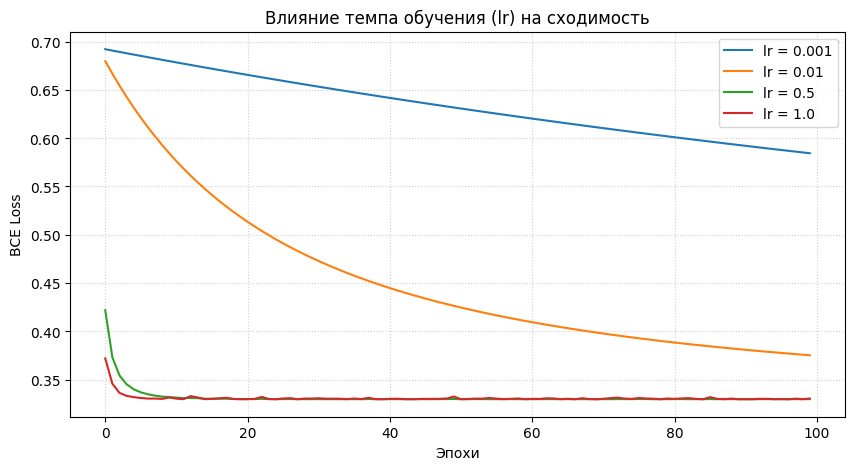

In [9]:
learning_rates = [0.001, 0.01, 0.5, 1.0]
plt.figure(figsize=(10, 5))

print(f"{'Learning Rate':<15} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 53)

for lr in learning_rates:
    np.random.seed(42)
    model_exp = Perceptron(input_size=2)
    hist_exp = model_exp.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, lr=lr, batch_size=32)

    tr_acc = accuracy_score(y_train.reshape(-1, 1), model_exp.predict(X_train_scaled))
    te_acc = accuracy_score(y_test.reshape(-1, 1), model_exp.predict(X_test_scaled))

    print(f"{lr:<15} | {tr_acc:<15.4f} | {te_acc:<15.4f}")
    plt.plot(hist_exp['train_loss'], label=f'lr = {lr}')

plt.title("Влияние темпа обучения (lr) на сходимость")
plt.xlabel("Эпохи")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Эксперимент 2: Влияние размера батча (batch size)
Опробуем значения `batch_size` $\in \{1, 16, 64, 256\}$ при фиксированном значении $\eta = 0.1$.

Batch Size      | Train Accuracy  | Test Accuracy  
-----------------------------------------------------
1               | 0.8632          | 0.8993         
16              | 0.8632          | 0.9060         
64              | 0.8575          | 0.8993         
256             | 0.8604          | 0.8993         


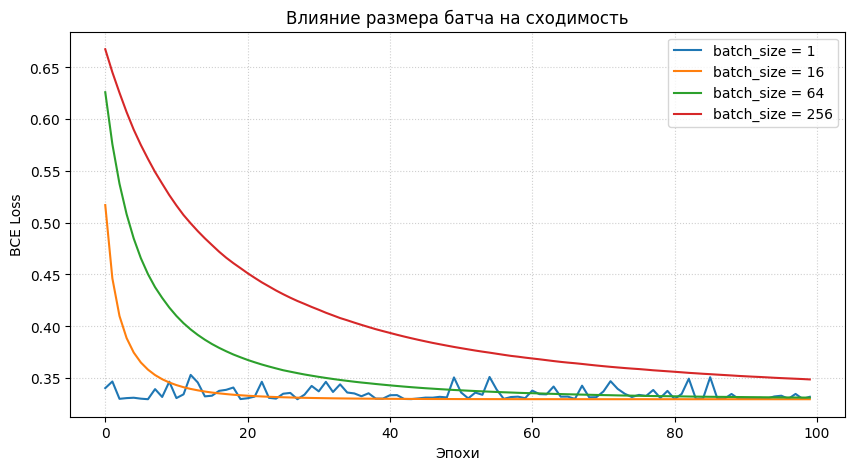

In [10]:
batch_sizes = [1, 16, 64, 256]
plt.figure(figsize=(10, 5))

print(f"{'Batch Size':<15} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 53)

for bs in batch_sizes:
    np.random.seed(42)
    model_exp = Perceptron(input_size=2)
    hist_exp = model_exp.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, lr=0.1, batch_size=bs)

    tr_acc = accuracy_score(y_train.reshape(-1, 1), model_exp.predict(X_train_scaled))
    te_acc = accuracy_score(y_test.reshape(-1, 1), model_exp.predict(X_test_scaled))

    print(f"{bs:<15} | {tr_acc:<15.4f} | {te_acc:<15.4f}")
    plt.plot(hist_exp['train_loss'], label=f'batch_size = {bs}')

plt.title("Влияние размера батча на сходимость")
plt.xlabel("Эпохи")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Эксперимент 3: Влияние инициализации весов
Сравним три типа инициализации:
1. Нулевая (`zeros`).
2. Маленькие случайные веса (`small_random`, по умолчанию).
3. Инициализация с большими значениями (`large_random`, из нормального распределения $\mathcal{N}(0, 10)$).

In [11]:
initializations = {
    "Zeros": lambda: (np.zeros((2, 1)), 0.0),
    "Small Random": lambda: (np.random.randn(2, 1) * 0.01, 0.0),
    "Large Random (N(0, 10))": lambda: (np.random.randn(2, 1) * 10.0, 0.0)
}

print(f"{'Init Method':<25} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 61)

for name, init_fn in initializations.items():
    np.random.seed(42)
    model_exp = Perceptron(input_size=2)
    # Ручная переинициализация весов
    model_exp.w, model_exp.b = init_fn()

    model_exp.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, lr=0.1, batch_size=32)

    tr_acc = accuracy_score(y_train.reshape(-1, 1), model_exp.predict(X_train_scaled))
    te_acc = accuracy_score(y_test.reshape(-1, 1), model_exp.predict(X_test_scaled))
    print(f"{name:<25} | {tr_acc:<15.4f} | {te_acc:<15.4f}")

Init Method               | Train Accuracy  | Test Accuracy  
-------------------------------------------------------------
Zeros                     | 0.8632          | 0.9060         
Small Random              | 0.8632          | 0.9060         
Large Random (N(0, 10))   | 0.8661          | 0.8993         
